---

**Machine Learning for Fraud Detection**  
**April 29, 2024**  
**Edouard Ratiarson**

This project involves constructing a Decision Tree Classifier to accurately detect fraudulent transactions within financial datasets. An exploratory data analysis primes our approach, followed by rigorous data preprocessing, which includes the employment of SMOTE to balance our dataset. We adopt cross-validation and grid search techniques to enhance the model's reliability and optimize its parameters. Advanced metrics such as AUC-ROC provide a nuanced evaluation of the classifier's performance. The assignment culminates in a thorough model analysis, offering insights into the classifier's decision-making process and the relative importance of different transactional features.

---

#1. Import Necessary Libraries
Start by importing all required libraries for data handling, machine learning, and visualization.

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from imblearn.over_sampling import SMOTE


#2. Load the Dataset
Load the dataset from a specified URL using pandas.

In [ ]:
# Load the dataset from a remote URL
url = 'https://raw.githubusercontent.com/marhcouto/fraud-detection/master/data/card_transdata.csv?raw=true'
data = pd.read_csv(url)


#3. Initial Data Exploration
Check the first few entries of the dataset and its summary statistics to understand the data structure.

In [ ]:
# Display the first 5 rows of the dataset
print("\n--- First 5 rows of data ---")
print(data.head(5))

# Display summary statistics to get an overview of the dataset
print("\n--- Summary Statistics ---")
print(data.describe())



--- First 5 rows of data ---
   distance_from_home  distance_from_last_transaction  \
0           57.877857                        0.311140   
1           10.829943                        0.175592   
2            5.091079                        0.805153   
3            2.247564                        5.600044   
4           44.190936                        0.566486   

   ratio_to_median_purchase_price  repeat_retailer  used_chip  \
0                        1.945940              1.0        1.0   
1                        1.294219              1.0        0.0   
2                        0.427715              1.0        0.0   
3                        0.362663              1.0        1.0   
4                        2.222767              1.0        1.0   

   used_pin_number  online_order  fraud  
0              0.0           0.0    0.0  
1              0.0           0.0    0.0  
2              0.0           1.0    0.0  
3              0.0           1.0    0.0  
4              0.0        

#4. Calculate Event Rate
Determine the frequency of fraudulent transactions to assess data imbalance.

In [ ]:
# Calculate and display the event rate of fraud cases
print("\n--- Event Rate ---")
event_rate = data['fraud'].mean() * 100
print(f'Event Rate: {event_rate:.2f}%')



--- Event Rate ---
Event Rate: 8.74%


#5. Data Preparation
Separate the dataset into features (X) and the target variable (y).

In [ ]:
# Define features (X) and target variable (y)
X = data.drop('fraud', axis=1)
y = data['fraud']


#6. Split the Data
Split the data into training and testing sets to prepare for model training and validation.

In [ ]:
# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#7. Data Balancing
Balance the training data using SMOTE to address the class imbalance problem.

In [ ]:
# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)


#8. Initialize and Train the Model
Configure and train a decision tree classifier on the balanced dataset.

In [ ]:
# Initialize and train a decision tree classifier on balanced data
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train_balanced, y_train_balanced)


DecisionTreeClassifier(max_depth=3)

#9. Make Predictions and Evaluate the Model
Evaluate the model using the testing set and various pe

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using accuracy, confusion matrix, and classification report
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Display the model's performance metrics
print("\n--- Model Performance Metrics ---")
print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(confusion)
print("Classification Report:")
print(classification_rep)



--- Model Performance Metrics ---
Accuracy: 0.98
Confusion Matrix:
[[178244   4313]
 [   517  16926]]
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99    182557
         1.0       0.80      0.97      0.88     17443

    accuracy                           0.98    200000
   macro avg       0.90      0.97      0.93    200000
weighted avg       0.98      0.98      0.98    200000



#10. Model Visualization
Visualize the decision tree to understand the decision-making process.

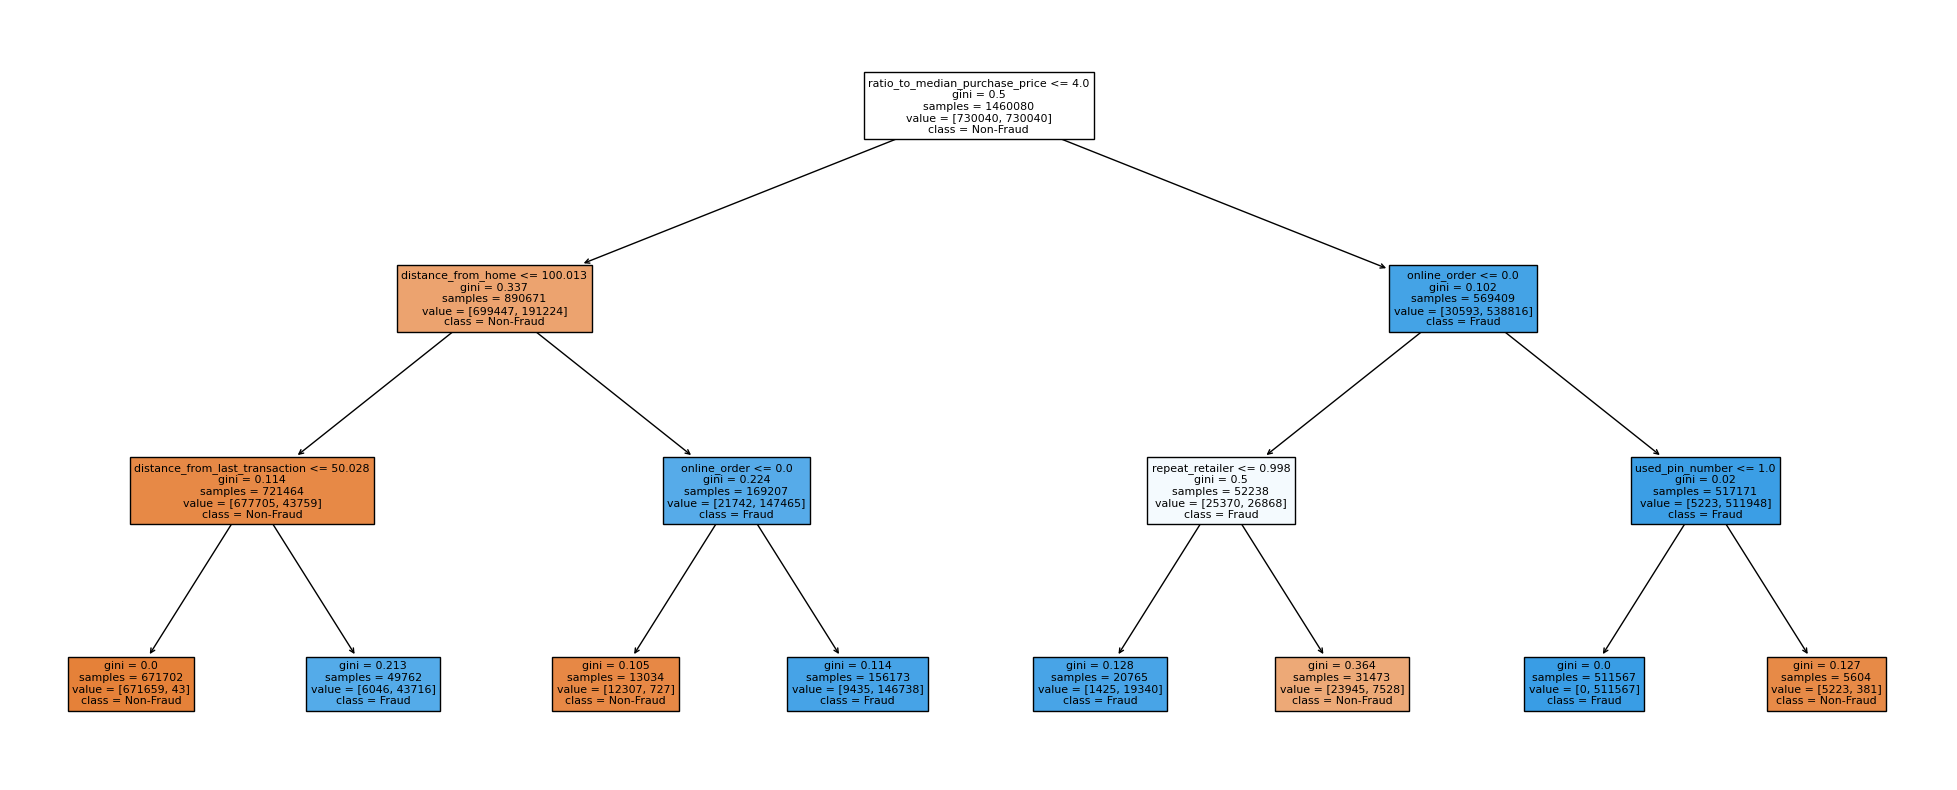

In [ ]:
# Visualize the decision tree
plt.figure(figsize=(25, 10))
plot_tree(model,
          filled=True,
          feature_names=X.columns.tolist(),
          class_names=['Non-Fraud', 'Fraud'])
plt.show()



**Decision Tree Analysis for Fraud Detection**

The decision tree visualization represents a model trained to classify transactions into 'Fraud' and 'Non-Fraud'. At each node of the tree, a decision is made based on the value of a particular feature, which effectively partitions the dataset. The root and subsequent nodes use measures such as Gini impurity to optimize these splits.

**Root Node:**
- The initial split is made on 'distance_from_home' <= 100.013, which indicates that transactions occurring a certain distance from home are more likely to be fraudulent. A higher Gini impurity (0.337) suggests this feature is significant in distinguishing between fraudulent and non-fraudulent transactions.

**First Level Splits:**
- On the left branch, transactions with 'distance_from_last_transaction' <= 50.028 are further investigated, which could imply that the proximity of transactions plays a role in fraud detection.
- On the right branch, 'ratio_to_median_purchase_price' <= 4.0 is used, suggesting that the transaction amount relative to the median purchase price is a crucial factor.

**Second Level Splits:**
- Further down, the tree considers 'online_order' <= 0.0, potentially indicating that offline transactions are less likely to be fraudulent.
- Additionally, 'repeat_retailer' and 'used_pin_number' are also evaluated, which are intuitive checks as repeated transactions at the same retailer and usage of a PIN number could be associated with the legitimacy of a transaction.

**Leaf Nodes and Class Assignments:**
- The tree's leaves show a final classification of 'Fraud' or 'Non-Fraud', with Gini impurity values aiming towards 0 for pure nodes.
- Particularly, one leaf node with a Gini impurity of 0.0 perfectly classifies transactions as non-fraudulent, implying that the path leading to this node is highly indicative of legitimate behavior.

**Feature Importance:**
- 'distance_from_home' and 'ratio_to_median_purchase_price' are used at the top splits, suggesting they are primary indicators of fraud in this model.
- 'online_order', 'repeat_retailer', and 'used_pin_number' appear as secondary but still relevant criteria, hinting at their predictive power in the context of this specific dataset.

**Model Insights:**
- The decision tree provides a clear and interpretable model for fraud detection. It highlights the importance of transaction location, amount, and behavioral patterns in detecting fraud.
- The class distribution at each leaf also reflects the data's balance or imbalance, which is pivotal when considering the model's performance metrics, such as precision and recall.

**Conclusions:**
- The decision tree's interpretability is a significant advantage, allowing analysts to understand the model's decision-making process.
- The chosen features for splits demonstrate an intuitive understanding of fraud characteristics.
- The model's simplicity should be balanced with its effectiveness; while a max depth of 3 prevents overfitting, it may limit the tree's ability to capture more complex fraud patterns.

Given these insights, the model appears to be a solid starting point for fraud detection, with room for further optimization and complexity if needed.


#11. Feature Importance Analysis and Cross-Validation
Analyze feature importance and perform cross-validation to assess the robustness of the model.

In [ ]:
# Analyze feature importance
importances = model.feature_importances_
feature_names = X.columns
feature_importance_dict = {name: importance for name, importance in zip(feature_names, importances)}
print("\n--- Feature Importances ---")
print(feature_importance_dict)

# Perform cross-validation
cv_scores = cross_val_score(model, X, y, cv=5)
print("\n--- Cross-Validation Scores ---")
print(cv_scores)
print("Average cross-validation score:", cv_scores.mean())



--- Feature Importances ---
{'distance_from_home': 0.2629545347254233, 'distance_from_last_transaction': 0.10431864790196538, 'ratio_to_median_purchase_price': 0.5424552471831424, 'repeat_retailer': 0.017490777840086517, 'used_chip': 0.0, 'used_pin_number': 0.014050460048543168, 'online_order': 0.05873033230083917}

--- Cross-Validation Scores ---
[0.97931  0.97937  0.97933  0.97979  0.979845]
Average cross-validation score: 0.979529


This complete guide covers data preparation, model training, evaluation, advanced techniques, and visualization to provide a comprehensive understanding of the process involved in fraud detection using a decision tree classifier.

---

**Conclusion**

Through strategic data preparation, model selection, and rigorous validation, this assignment has demonstrated a viable approach to detecting fraudulent transactions using a Decision Tree Classifier. The balance between model complexity and interpretability has been carefully navigated, ensuring not only high accuracy but also the maintainability and understandability of the model's decisions. The employment of SMOTE for addressing class imbalance and the utilization of cross-validation for model robustness underscore the thoroughness of the methodology applied. The insights gained from feature importance and model explainability tools have provided a deeper understanding of the predictive dynamics at play. As the financial industry continues to grapple with the menace of fraud, the methodologies refined and applied here offer a promising avenue for enhancing security and trust in financial transactions.

---